# Playbook

# ## Land Cover Classification with K Mean



## Cell 1: Setup and Imports

In [1]:
%matplotlib widget
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import os

# Configuration
image_path = r"D:/tasks/t01_playground/aerial_images_lux/aerial_aoi_lux_2023.tif"
lidar_path = r"D:/tasks/t01_playground/lidar/lidar_nDSM2024_aoi.tif"
output_dir = r"D:\tasks\t01_playground\tmp_results"
output_path = os.path.join(output_dir, "fast_unsupervised_classification.tif")
os.makedirs(output_dir, exist_ok=True)


## Cell 2: Load and Preprocess Image

In [2]:
# %% Load and combine image and LiDAR data
# Load aerial image
with rasterio.open(image_path) as src:
    img = src.read()
    profile = src.profile
    height, width = src.height, src.width
    transform = src.transform
    crs = src.crs
    print(f"✓ Image loaded: {img.shape} (bands, height, width)")

# Load LiDAR data
with rasterio.open(lidar_path) as lidar_src:
    lidar = lidar_src.read(1)  # Read first band (nDSM)
    print(f"✓ LiDAR loaded: {lidar.shape}")

    # Check if resampling is needed
    if lidar.shape != (height, width):
        print("⚠ LiDAR dimensions don't match image, resampling...")
        from rasterio.warp import reproject, Resampling

        # Create destination array with same dimensions as image
        lidar_resampled = np.empty((height, width), dtype=lidar.dtype)

        # Use the image's transform and CRS as destination
        reproject(
            source=lidar,
            destination=lidar_resampled,
            src_transform=lidar_src.transform,
            src_crs=lidar_src.crs,
            dst_transform=transform,  # Use image's transform
            dst_crs=crs,               # Use image's CRS
            resampling=Resampling.bilinear
        )
        lidar = lidar_resampled
        print(f"✓ LiDAR resampled to: {lidar.shape}")

# Stack LiDAR as an additional band
img_with_lidar = np.concatenate([img, lidar[np.newaxis, ...]], axis=0)
print(f"✓ Combined data: {img_with_lidar.shape} (bands, height, width)")

# Reshape for sklearn: (height * width, bands)
img_reshaped = img_with_lidar.transpose(1, 2, 0).reshape(-1, img_with_lidar.shape[0])
print(f"✓ Data reshaped: {img_reshaped.shape} (pixels, bands)")

# Standardize the data (CRITICAL for K-Means)
scaler = StandardScaler()
img_scaled = scaler.fit_transform(img_reshaped)
print(f"✓ Data standardized: {img_scaled.shape} (pixels, bands)")


✓ Image loaded: (3, 2000, 3200) (bands, height, width)
✓ LiDAR loaded: (400, 640)
⚠ LiDAR dimensions don't match image, resampling...
✓ LiDAR resampled to: (2000, 3200)
✓ Combined data: (4, 2000, 3200) (bands, height, width)
✓ Data reshaped: (6400000, 4) (pixels, bands)
✓ Data standardized: (6400000, 4) (pixels, bands)


##  Cell 3: Apply K-Means Clustering (minibatch)

In [3]:

# %% MiniBatch K-Means
n_clusters = 5
mbk = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=1000,
    n_init=3,
    random_state=42,
    max_iter=100
)
clusters = mbk.fit_predict(img_scaled)
classified_img = clusters.reshape(height, width)
print(f"✓ MiniBatch K-Means complete (n_clusters={n_clusters})")


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


✓ MiniBatch K-Means complete (n_clusters=5)


## Cell 4: save

In [4]:
# %% Save results
with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=classified_img.dtype,
    crs=crs,
    transform=transform
) as dst:
    dst.write(classified_img.astype(np.uint8), 1)
print(f"✓ Results saved to: {output_path}")

✓ Results saved to: D:\tasks\t01_playground\tmp_results\fast_unsupervised_classification.tif


## Cell 5: Visualize Clusters

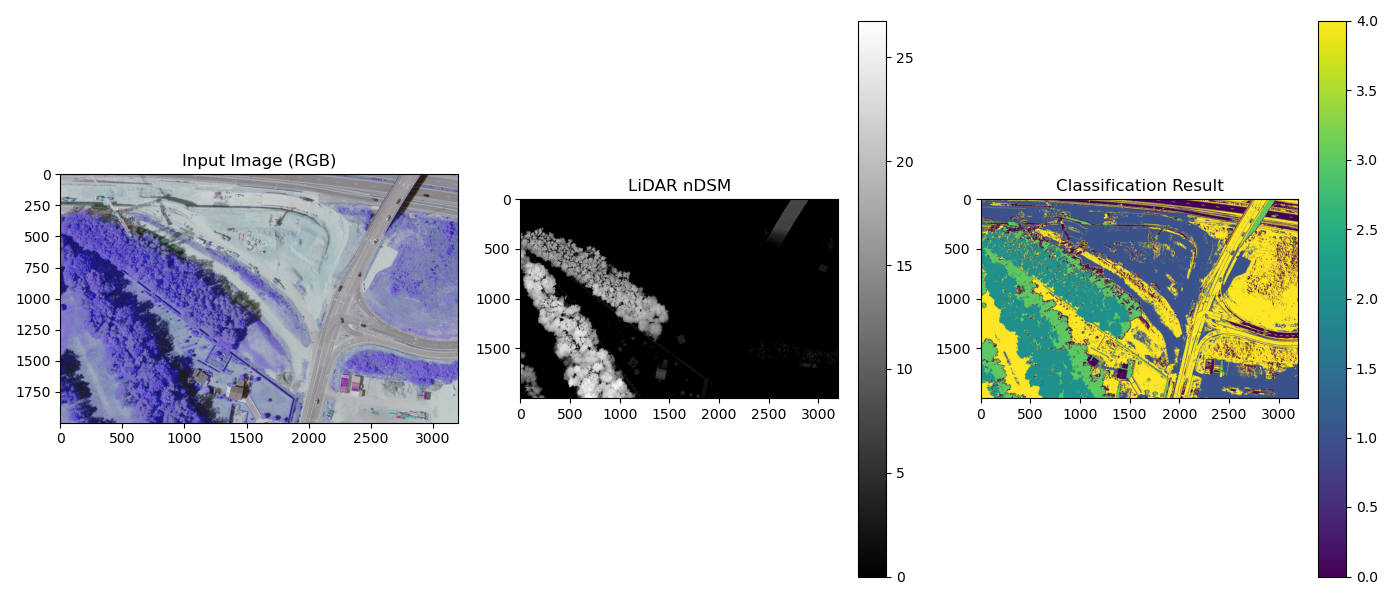

In [5]:
# %% Visualize results
plt.figure(figsize=(14, 6))

# Show RGB composite (assuming bands are R,G,B,NIR or similar)
rgb_bands = [2, 1, 0]  # Adjust these indices based on your actual band order
if img.shape[0] >= 3:
    plt.subplot(131)
    plt.imshow(img[rgb_bands, :, :].transpose(1, 2, 0))
    plt.title('Input Image (RGB)')

# Show LiDAR
plt.subplot(132)
plt.imshow(lidar, cmap='gray')
plt.title('LiDAR nDSM')
plt.colorbar()

# Show classification
plt.subplot(133)
plt.imshow(classified_img, cmap='viridis')
plt.title('Classification Result')
plt.colorbar()

plt.tight_layout()
plt.show()